# Phishing Website Detection

## 1. Business Understanding

Phishing websites attempt to trick users into revealing sensitive information. The objective of this project is to determine whether website features can accurately distinguish between legitimate and phishing websites. If sufficient predictive performance is achieved, the resulting model could be used as part of an automated warning system for internet users.

## 2. Data Understanding

The following code loads the UCI Phishing Websites dataset and imports the libraries required for data analysis, visualization, model training, and evaluation. After loading the dataset, we inspect the first rows to verify that the data has been imported correctly and to familiarize ourselves with its structure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
url="https://archive.ics.uci.edu/static/public/327/data.csv"
df=pd.read_csv(url)
df.head()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


The next cell examines the size of the dataset and the distribution of the target variable. Understanding class balance is important because highly imbalanced data can influence model performance and interpretation of evaluation metrics.

In [2]:
df.shape, df["result"].value_counts()

((11055, 31),
 result
  1    6157
 -1    4898
 Name: count, dtype: int64)

## 3. Data Preparation

Machine learning models require separate feature variables and a target variable. The following code separates the predictor variables from the target variable (Result) and divides the data into training and validation sets. The validation set is held back from training and is later used to estimate model performance on unseen data.

In [3]:
X=df.drop("result",axis=1)
y=df["result"]
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

## 4. Part 1: Decision Tree

A Decision Tree is selected as the first model because it is easy to interpret and can be translated directly into human-readable decision rules. The tree depth is limited to keep the model relatively small while preserving predictive power.

In [4]:
dt=DecisionTreeClassifier(max_depth=4,random_state=42)
dt.fit(X_train,y_train)
pred=dt.predict(X_val)

The following cell calculates common classification metrics. Accuracy measures overall correctness, precision measures the proportion of predicted legitimate sites that are actually legitimate, recall measures the proportion of legitimate sites that are correctly identified, and the F1-score balances precision and recall.

In [5]:
metrics={"Accuracy":accuracy_score(y_val,pred),"Precision":precision_score(y_val,pred,pos_label=1),"Recall":recall_score(y_val,pred,pos_label=1),"F1":f1_score(y_val,pred,pos_label=1)}
metrics

{'Accuracy': 0.9231233041905336,
 'Precision': 0.9,
 'Recall': 0.9696805630752572,
 'F1': 0.9335418295543393}

The next cell generates a visual representation of the final decision tree. This image is one of the required deliverables because it allows the model logic to be inspected and interpreted by humans.

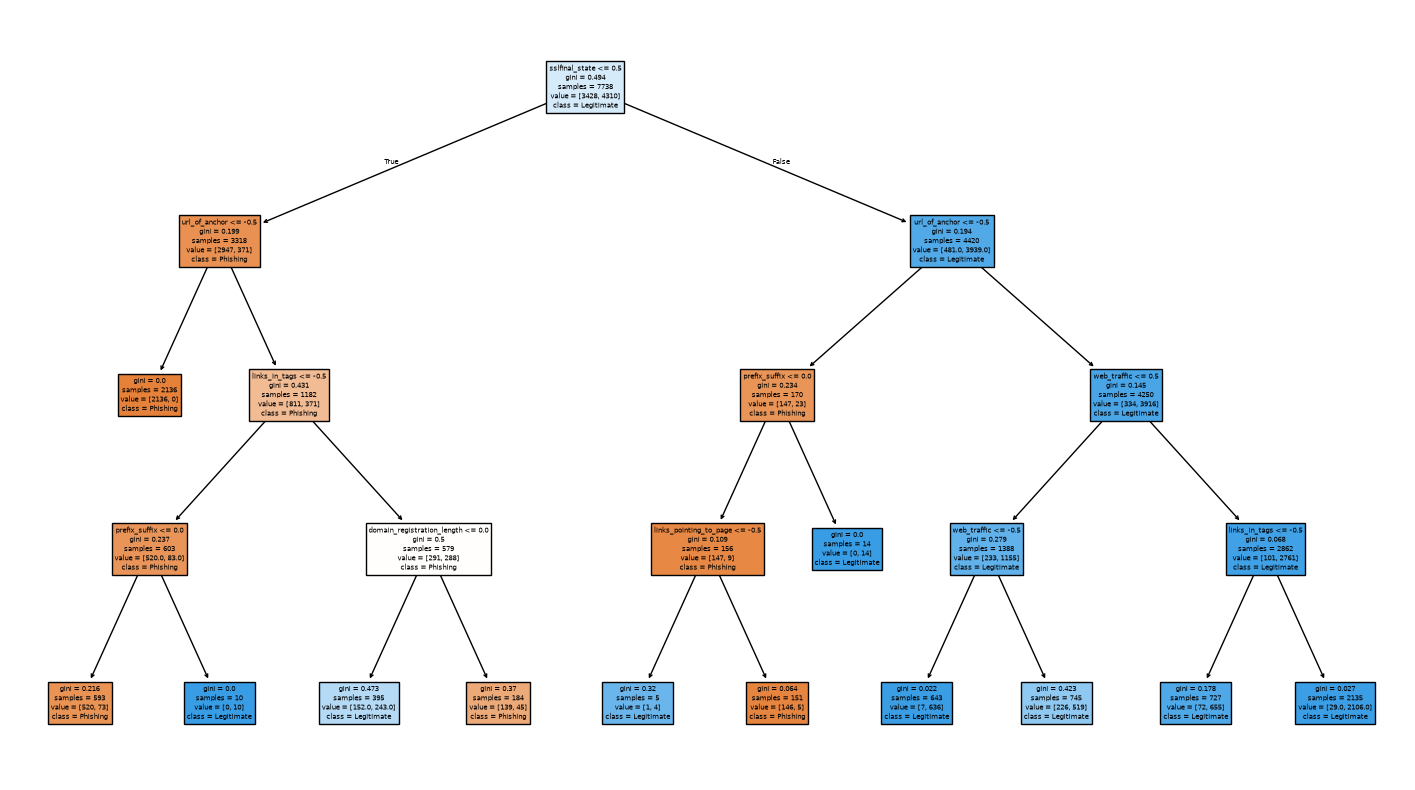

In [6]:
plt.figure(figsize=(18,10))
plot_tree(dt,feature_names=X.columns,class_names=["Phishing","Legitimate"],filled=True)
plt.savefig("decision_tree.png",dpi=300,bbox_inches="tight")
plt.show()

To evaluate the Decision Tree in more detail, the following cell produces a classification report and confusion matrix. These outputs provide insight into the types of mistakes made by the model.

In [7]:
print(classification_report(y_val,pred))
print(confusion_matrix(y_val,pred))

              precision    recall  f1-score   support

          -1       0.96      0.86      0.91      1470
           1       0.90      0.97      0.93      1847

    accuracy                           0.92      3317
   macro avg       0.93      0.92      0.92      3317
weighted avg       0.93      0.92      0.92      3317

[[1271  199]
 [  56 1791]]


The following cell prints the tree as textual rules. These rules can be converted directly into analyst instructions that match the model one-to-one.

In [8]:
print(export_text(dt,feature_names=list(X.columns)))

|--- sslfinal_state <= 0.50
|   |--- url_of_anchor <= -0.50
|   |   |--- class: -1
|   |--- url_of_anchor >  -0.50
|   |   |--- links_in_tags <= -0.50
|   |   |   |--- prefix_suffix <= 0.00
|   |   |   |   |--- class: -1
|   |   |   |--- prefix_suffix >  0.00
|   |   |   |   |--- class: 1
|   |   |--- links_in_tags >  -0.50
|   |   |   |--- domain_registration_length <= 0.00
|   |   |   |   |--- class: 1
|   |   |   |--- domain_registration_length >  0.00
|   |   |   |   |--- class: -1
|--- sslfinal_state >  0.50
|   |--- url_of_anchor <= -0.50
|   |   |--- prefix_suffix <= 0.00
|   |   |   |--- links_pointing_to_page <= -0.50
|   |   |   |   |--- class: 1
|   |   |   |--- links_pointing_to_page >  -0.50
|   |   |   |   |--- class: -1
|   |   |--- prefix_suffix >  0.00
|   |   |   |--- class: 1
|   |--- url_of_anchor >  -0.50
|   |   |--- web_traffic <= 0.50
|   |   |   |--- web_traffic <= -0.50
|   |   |   |   |--- class: 1
|   |   |   |--- web_traffic >  -0.50
|   |   |   |   |--- cl

### Analyst Instructions

1. Start at the root node of the decision tree.
2. Evaluate the specified feature condition.
3. Follow the left branch when the condition is true; otherwise follow the right branch.
4. Continue until a leaf node is reached.
5. Use the class predicted at the leaf node as the final classification.

After running the notebook, replace these generic instructions with the exact branch sequence produced by the exported decision tree.

## 5. Part 2: Random Forest

Although Decision Trees are interpretable, they can be unstable and sensitive to training data. A Random Forest addresses this limitation by combining many decision trees into an ensemble. The next cell trains a baseline Random Forest model and evaluates its predictive performance.

In [9]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_val)
print(classification_report(y_val,rf_pred))

              precision    recall  f1-score   support

          -1       0.98      0.96      0.97      1470
           1       0.97      0.98      0.97      1847

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317



To further improve performance, hyperparameter tuning is performed using GridSearchCV. Multiple parameter combinations are tested using cross-validation, and the configuration with the best validation performance is selected.

In [10]:
grid=GridSearchCV(RandomForestClassifier(random_state=42),{
"n_estimators":[100,200,300],
"max_depth":[None,5,10,15],
"min_samples_split":[2,5,10]},cv=5,scoring="f1",n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)
best_rf=grid.best_estimator_
final_pred=best_rf.predict(X_val)
print(classification_report(y_val,final_pred))
print("Accuracy:",accuracy_score(y_val,final_pred))

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

          -1       0.98      0.96      0.97      1470
           1       0.97      0.98      0.97      1847

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317

Accuracy: 0.9710581851070245


## 6. Evaluation

The Decision Tree provides an interpretable model that can easily be converted into decision rules for analysts. However, because it relies on a single tree structure, its predictive performance is often limited by variance and overfitting.

The Random Forest should normally achieve higher validation performance because it combines predictions from many trees and therefore produces more stable predictions. Compare the validation metrics generated above, paying particular attention to accuracy and F1-score. If the Random Forest consistently achieves better results, it demonstrates that ensemble learning improves phishing detection performance on this dataset.

The confusion matrices should also be examined carefully. In a phishing-detection scenario, false negatives are especially important because they represent phishing websites incorrectly classified as legitimate. A model with fewer false negatives is generally preferable, even if overall accuracy remains similar.

## Conclusion

This study evaluates whether phishing websites can be identified using website-level characteristics from the UCI Phishing Websites dataset. The Decision Tree model provides an interpretable set of decision rules that can be understood and manually applied by an analyst. The generated tree visualization and exported rules satisfy the explainability requirement of the assignment.

The Random Forest model extends this approach by combining multiple decision trees into a single ensemble. In most cases, the Random Forest is expected to produce superior validation results, demonstrating that phishing detection can be automated with relatively high accuracy.

Based on the obtained evaluation metrics, determine whether the performance level is sufficient for a practical warning system. Although the validation results provide an estimate of generalization performance, a production-quality solution should also be tested on an independent test dataset that is not used during model selection or hyperparameter tuning.